#Project 1: Fast Food Marketing Campaign A/B Test

Name: Feras Alfarasi

In [53]:
# Standard libraries
from pathlib import Path

# Installed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Paths
df = Path('WA_Marketing-Campaign.csv')
df = pd.read_csv(df)


In [57]:
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [58]:
df.tail()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
543,10,Large,919,2,1,4,64.34
544,10,Large,920,14,2,1,50.20
545,10,Large,920,14,2,2,45.75
546,10,Large,920,14,2,3,44.29
547,10,Large,920,14,2,4,49.41


In [60]:
df.dtypes

MarketID              int64
MarketSize              str
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object

In [34]:
len(df)


548

##show full technical details of the DataFrame

In [35]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB


In [36]:
df.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


## Show index

In [61]:
df.index

RangeIndex(start=0, stop=548, step=1)

## Show labels

In [62]:
df.columns

Index(['MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion',
       'week', 'SalesInThousands'],
      dtype='str')

In [67]:
some_column = df[['MarketID','SalesInThousands','Promotion']]
some_column.tail()

,MarketID,SalesInThousands,Promotion
543,10,64.34,1
544,10,50.20,2
545,10,45.75,2
546,10,44.29,2
547,10,49.41,2


In [72]:
condition = df[df['SalesInThousands'] > 50]
condition

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
26,1,Medium,7,15,1,3,51.72
48,1,Medium,13,12,1,1,50.48
52,2,Small,101,22,1,1,67.48
53,2,Small,101,22,1,2,65.57
54,2,Small,101,22,1,3,68.42
...,...,...,...,...,...,...,...
540,10,Large,919,2,1,1,59.87
541,10,Large,919,2,1,2,62.99
542,10,Large,919,2,1,3,57.20
543,10,Large,919,2,1,4,64.34


In [74]:
markpet_sales = df['SalesInThousands'] > 45
markpet_sales

0      False
1      False
2      False
3      False
4      False
       ...  
543     True
544     True
545     True
546    False
547     True
Name: SalesInThousands, Length: 548, dtype: bool

In [79]:
markpet_sales = df['SalesInThousands'].isin([15, 20])
markpet_sales

0      False
1      False
2      False
3      False
4      False
       ...  
543    False
544    False
545    False
546    False
547    False
Name: SalesInThousands, Length: 548, dtype: bool

In [92]:
above_2 =  df.loc[df["week"] > 2 , "MarketID"]
above_2

2       1
3       1
6       1
7       1
10      1
       ..
539    10
542    10
543    10
546    10
547    10
Name: MarketID, Length: 274, dtype: int64

In [96]:
condition = (df["AgeOfStore"] > 10) & (df['MarketSize'] == 'Medium')
columns = ["MarketID", 'LocationID']

result = df.loc[condition, columns]
result

,MarketID,LocationID
8,1,3
9,1,3
10,1,3
11,1,3
24,1,7
...,...,...
459,9,808
464,9,810
465,9,810
466,9,810


In [106]:
df[5:10]

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
5,1,Medium,2,5,2,2,34.67
6,1,Medium,2,5,2,3,27.98
7,1,Medium,2,5,2,4,27.72
8,1,Medium,3,12,1,1,44.54
9,1,Medium,3,12,1,2,37.94


In [104]:
df['SalesInThousands'].value_counts()

SalesInThousands
47.22    3
51.09    3
39.25    2
42.16    2
51.72    2
        ..
57.20    1
64.34    1
45.75    1
44.29    1
49.41    1
Name: count, Length: 517, dtype: int64

In [105]:
df["SalesInThousands"].mean()

np.float64(53.46620437956205)

In [107]:
df["AgeOfStore"].describe()

count    548.000000
mean       8.503650
std        6.638345
min        1.000000
25%        4.000000
50%        7.000000
75%       12.000000
max       28.000000
Name: AgeOfStore, dtype: float64

In [110]:
df[["Promotion", "AgeOfStore"]].median()

Promotion     2.0
AgeOfStore    7.0
dtype: float64

In [111]:
df[["Promotion", "AgeOfStore"]].agg(
    {
        "Promotion": ["min", "max", "median", "skew"],
        "AgeOfStore": ["min", "max", "median", "mean"],
    }
)

,Promotion,AgeOfStore
min,1.00000,1.00000
max,3.00000,28.00000
median,2.00000,7.00000
skew,-0.05339,NaN
mean,NaN,8.50365


In [117]:
agg = df[["Promotion", "SalesInThousands"]].groupby("Promotion").mean()
agg

,SalesInThousands
Promotion,
1,58.099012
2,47.329415
3,55.364468


In [130]:
df.groupby("SalesInThousands").mean(numeric_only=True)


,MarketID,LocationID,AgeOfStore,Promotion,week
SalesInThousands,,,,,
17.34,6.0,507.0,5.0,2.0,2.0
19.26,6.0,506.0,12.0,2.0,4.0
22.18,1.0,6.0,10.0,3.0,2.0
23.35,1.0,5.0,10.0,2.0,4.0
23.44,6.0,507.0,5.0,2.0,4.0
...,...,...,...,...,...
96.01,3.0,209.0,1.0,1.0,2.0
96.48,3.0,208.0,1.0,3.0,1.0
97.61,3.0,209.0,1.0,1.0,4.0


In [133]:
df.groupby("Promotion")["SalesInThousands"].mean()

Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

In [134]:
df.groupby("MarketSize")["SalesInThousands"].mean()

MarketSize
Large     70.116726
Medium    43.985344
Small     57.409333
Name: SalesInThousands, dtype: float64

In [137]:
df.groupby("MarketSize")["Promotion"].mean()

MarketSize
Large     1.952381
Medium    2.062500
Small     2.066667
Name: Promotion, dtype: float64

In [138]:
df.groupby("MarketSize")["AgeOfStore"].mean()

MarketSize
Large      7.142857
Medium     8.787500
Small     10.800000
Name: AgeOfStore, dtype: float64

In [140]:
df.groupby("AgeOfStore")["SalesInThousands"].mean()

AgeOfStore
1     58.415625
2     59.179500
3     60.227500
4     53.437727
5     48.818636
6     51.366667
7     52.128750
8     50.475750
9     48.996071
10    39.313750
11    57.159375
12    47.482917
13    59.642500
14    49.063333
15    42.673750
17    49.937500
18    50.710000
19    63.638000
20    60.202500
22    59.688333
23    65.097500
24    51.140833
25    45.425000
27    52.392500
28    52.285000
Name: SalesInThousands, dtype: float64

In [146]:
df["MarketSize"].value_counts()

MarketSize
Medium    320
Large     168
Small      60
Name: count, dtype: int64

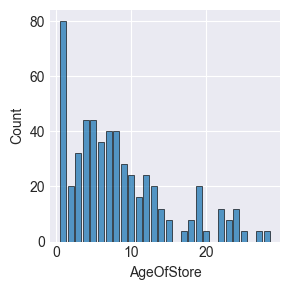

In [147]:
sns.displot(
    data=df,
    kind='hist', # Histogram
    discrete=True, shrink=0.8, # Categorical
    x='AgeOfStore', # Variable to plot on the x-axis
    height=3, aspect=1 # Figure size
)

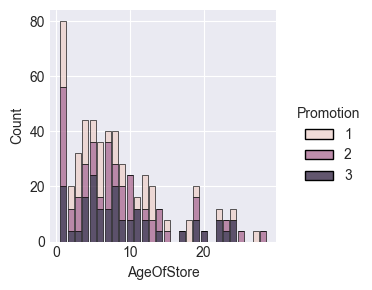

In [151]:
sns.displot(
    data=df,
    kind='hist',
    discrete=True, shrink=0.8,
    height=3, aspect=1,
    
    x='AgeOfStore',
    hue='Promotion',        # Distinguish color by this categorical variable
    multiple='stack', # Put next to each other (try: "stack" and "fill")
)

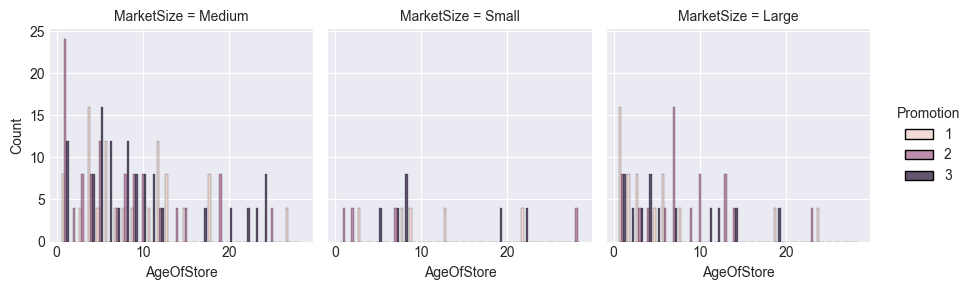

In [154]:
sns.displot(
    data=df,
    kind='hist',
    discrete=True, shrink=0.8,
    height=3, aspect=1,
    
    x='AgeOfStore',
    hue='Promotion',        # Distinguish color by this categorical variable
    multiple='dodge',
    col='MarketSize',    # Try row instead of col
)

In [157]:
counts = df['MarketSize'].value_counts()
counts

MarketSize
Medium    320
Large     168
Small      60
Name: count, dtype: int64

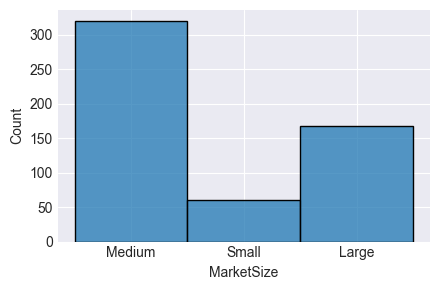

In [159]:
sns.displot(
    df, kind='hist',
    x='MarketSize',
    aspect=1.5, height=3
)

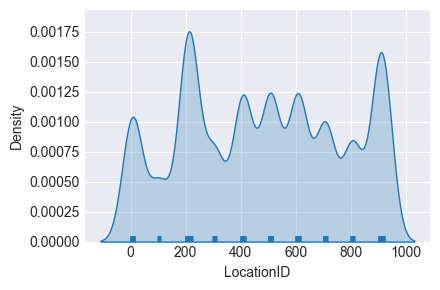

In [163]:
sns.displot(
    df,
    x='LocationID',
    aspect=1.5, height=3,
    
    kind='kde',     # Curve
    fill=True,      # Fill-in with color
    rug=True,       # Show actual where samples are
    bw_adjust=0.45  # Curve smoothness
)

In [164]:
df['LocationID'].describe()

count    548.000000
mean     479.656934
std      287.973679
min        1.000000
25%      216.000000
50%      504.000000
75%      708.000000
max      920.000000
Name: LocationID, dtype: float64

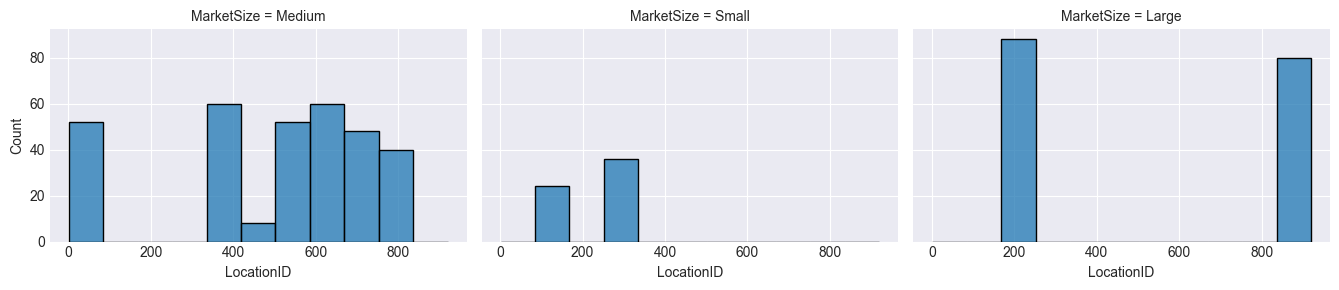

In [167]:
sns.displot(
    data=df,
    x="LocationID", col="MarketSize",
    aspect=1.5, height=3,
)

In [38]:
print("Number of items:", len(df))
print("Sum:", df['MarketID'].sum())
print("Average:", df['MarketID'].mean())
print("Median:", df['MarketID'].median(),)
print("Mode:", df['MarketID'].mode()[0])
print("Standard Deviation:", df['MarketID'].std())

Number of items: 548
Sum: 3132
Average: 5.7153284671532845
Median: 6.0
Mode: 3
Standard Deviation: 2.8770005330925525


In [39]:
df['SalesInThousands'] > 45

0      False
1      False
2      False
3      False
4      False
       ...  
543     True
544     True
545     True
546    False
547     True
Name: SalesInThousands, Length: 548, dtype: bool

In [40]:
df.groupby(by='SalesInThousands').describe()

MarketID                                   LocationID         \
                    count mean std  min  25%  50%  75%  max      count   mean   
SalesInThousands                                                                
17.34                 1.0  6.0 NaN  6.0  6.0  6.0  6.0  6.0        1.0  507.0   
19.26                 1.0  6.0 NaN  6.0  6.0  6.0  6.0  6.0        1.0  506.0   
22.18                 1.0  1.0 NaN  1.0  1.0  1.0  1.0  1.0        1.0    6.0   
23.35                 1.0  1.0 NaN  1.0  1.0  1.0  1.0  1.0        1.0    5.0   
23.44                 1.0  6.0 NaN  6.0  6.0  6.0  6.0  6.0        1.0  507.0   
...                   ...  ...  ..  ...  ...  ...  ...  ...        ...    ...   
96.01                 1.0  3.0 NaN  3.0  3.0  3.0  3.0  3.0        1.0  209.0   
96.48                 1.0  3.0 NaN  3.0  3.0  3.0  3.0  3.0        1.0  208.0   
97.61                 1.0  3.0 NaN  3.0  3.0  3.0  3.0  3.0        1.0  209.0   
99.12                 1.0  3.0 NaN  3.0  3.0  3.0  3.0  3.0        1.0  220.0   
99.65                 1.0  3.0 NaN  3.0  3.0  3.0  3.0  3.0        1.0  218.0   

                                                        AgeOfStore            \
                 std    min    25%    50%    75%    max      count  mean std   
SalesInThousands                                                               
17.34            NaN  507.0  507.0  507.0  507.0  507.0        1.0   5.0 NaN   
19.26            NaN  506.0  506.0  506.0  506.0  506.0        1.0  12.0 NaN   
22.18            NaN    6.0    6.0    6.0    6.0    6.0        1.0  10.0 NaN   
23.35            NaN    5.0    5.0    5.0    5.0    5.0        1.0  10.0 NaN   
23.44            NaN  507.0  507.0  507.0  507.0  507.0        1.0   5.0 NaN   
...               ..    ...    ...    ...    ...    ...        ...   ...  ..   
96.01            NaN  209.0  209.0  209.0  209.0  209.0        1.0   1.0 NaN   
96.48            NaN  208.0  208.0  208.0  208.0  208.0        1.0   1.0 NaN   
97.61            NaN  209.0  209.0  209.0  209.0  209.0        1.0   1.0 NaN   
99.12            NaN  220.0  220.0  220.0  220.0  220.0        1.0   3.0 NaN   
99.65            NaN  218.0  218.0  218.0  218.0  218.0        1.0   2.0 NaN   

                                               Promotion                     \
                   min   25%   50%   75%   max     count mean std  min  25%   
SalesInThousands                                                              
17.34              5.0   5.0   5.0   5.0   5.0       1.0  2.0 NaN  2.0  2.0   
19.26             12.0  12.0  12.0  12.0  12.0       1.0  2.0 NaN  2.0  2.0   
22.18             10.0  10.0  10.0  10.0  10.0       1.0  3.0 NaN  3.0  3.0   
23.35             10.0  10.0  10.0  10.0  10.0       1.0  2.0 NaN  2.0  2.0   
23.44              5.0   5.0   5.0   5.0   5.0       1.0  2.0 NaN  2.0  2.0   
...                ...   ...   ...   ...   ...       ...  ...  ..  ...  ...   
96.01              1.0   1.0   1.0   1.0   1.0       1.0  1.0 NaN  1.0  1.0   
96.48              1.0   1.0   1.0   1.0   1.0       1.0  3.0 NaN  3.0  3.0   
97.61              1.0   1.0   1.0   1.0   1.0       1.0  1.0 NaN  1.0  1.0   
99.12              3.0   3.0   3.0   3.0   3.0       1.0  1.0 NaN  1.0  1.0   
99.65              2.0   2.0   2.0   2.0   2.0       1.0  1.0 NaN  1.0  1.0   

                                 week                                    
                  50%  75%  max count mean std  min  25%  50%  75%  max  
SalesInThousands                                                         
17.34             2.0  2.0  2.0   1.0  2.0 NaN  2.0  2.0  2.0  2.0  2.0  
19.26             2.0  2.0  2.0   1.0  4.0 NaN  4.0  4.0  4.0  4.0  4.0  
22.18             3.0  3.0  3.0   1.0  2.0 NaN  2.0  2.0  2.0  2.0  2.0  
23.35             2.0  2.0  2.0   1.0  4.0 NaN  4.0  4.0  4.0  4.0  4.0  
23.44             2.0  2.0  2.0   1.0  4.0 NaN  4.0  4.0  4.0  4.0  4.0  
...               ...  ...  ...   ...  ...  ..  ...  ...  ... 

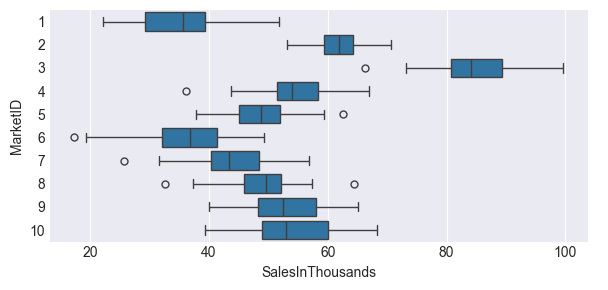

In [41]:
sns.catplot(
    data=df,
    kind='box',
    x='SalesInThousands',
    y='MarketID',
    orient='h',
    height=3, # vertical scale
    aspect=2  # Maintain proportion
)

In [43]:
partial_census_df = df[['MarketID', 'LocationID', 'AgeOfStore', 'SalesInThousands']]
		
partial_census_df

,MarketID,LocationID,AgeOfStore,SalesInThousands
0,1,1,4,33.73
1,1,1,4,35.67
2,1,1,4,29.03
3,1,1,4,39.25
4,1,2,5,27.81
...,...,...,...,...
543,10,919,2,64.34
544,10,920,14,50.20
545,10,920,14,45.75
546,10,920,14,44.29


In [50]:
mask = partial_census_df['AgeOfStore'] == 6
partial_census_df[mask]

,MarketID,LocationID,AgeOfStore,SalesInThousands
32,1,9,6,37.41
33,1,9,6,38.64
34,1,9,6,40.90
35,1,9,6,41.11
160,3,222,6,93.32
161,3,222,6,85.71
162,3,222,6,77.36
163,3,222,6,91.29
224,5,407,6,45.56
225,5,407,6,55.19


In [51]:
mask1 = (partial_census_df['AgeOfStore'] >= 7)
mask2 = (partial_census_df['AgeOfStore'] <= 10)
mask = mask1 & mask2
partial_census_df[mask]

,MarketID,LocationID,AgeOfStore,SalesInThousands
16,1,5,10,30.37
17,1,5,10,24.82
18,1,5,10,37.47
19,1,5,10,23.35
20,1,6,10,32.90
...,...,...,...,...
523,10,914,9,45.90
528,10,916,7,43.61
529,10,916,7,46.20
530,10,916,7,51.52
